# Notebook 03 - Visualizacion de Atencion

## Objetivos
- Extraer pesos de atencion de DistilBERT.
- Construir heatmaps interpretables.
- Analizar frases con ambiguedad desde CSV.

## Introduccion
Ver la matriz de atencion ayuda a entender que tokens 'miran' a cuales. Usaremos `distilbert-base-uncased` con `output_attentions=True`.

In [3]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModel

RUTA_FRASES = Path('..') / 'datasets' / 'frases_atencion.csv'
print('Ruta datasets:', RUTA_FRASES.exists())

Ruta datasets: True


## 1) Cargar frases de atencion

In [4]:
# Leemos el CSV con frases categorizadas
df_frases = pd.read_csv(RUTA_FRASES)
display(df_frases.head())
print('Total frases:', len(df_frases))

,id,frase,nota
0,1,El perro mordió al hombre porque él estaba asu...,ambiguedad_pronombre
1,2,La profesora felicitó a la estudiante porque e...,ambiguedad_pronombre
2,3,El banco cerró temprano porque llovió mucho.,ambiguedad_lexica
3,4,Fui al banco del parque a leer un libro.,ambiguedad_lexica
4,5,El gato persigió al ratón hasta que se escondió.,ambiguedad_pronombre


Total frases: 15


## 2) Cargar DistilBERT con salida de atenciones

In [5]:
# Nombre del modelo ligero en ingles
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()  # Modo inferencia
print('Modelo cargado:', model_name)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Modelo cargado: distilbert-base-uncased


c:\Users\juand\anaconda3\envs\tf_windows\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\juand\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## 3) Funcion para obtener matriz de atencion

In [6]:
def obtener_atencion(frase: str, capa: int = -1, cabeza: int = 0):
    """Devuelve tokens y matriz de atencion de una cabeza especifica."""
    inputs = tokenizer(frase, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)
    # outputs.attentions es tupla por capa
    attn = outputs.attentions[capa][0, cabeza].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    return tokens, attn

tokens_demo, attn_demo = obtener_atencion('The cat chased the mouse')
print('Tokens:', tokens_demo)
print('Shape atencion:', attn_demo.shape)

Tokens: ['[CLS]', 'the', 'cat', 'chased', 'the', 'mouse', '[SEP]']
Shape atencion: (7, 7)


## 4) Heatmap con matplotlib y seaborn

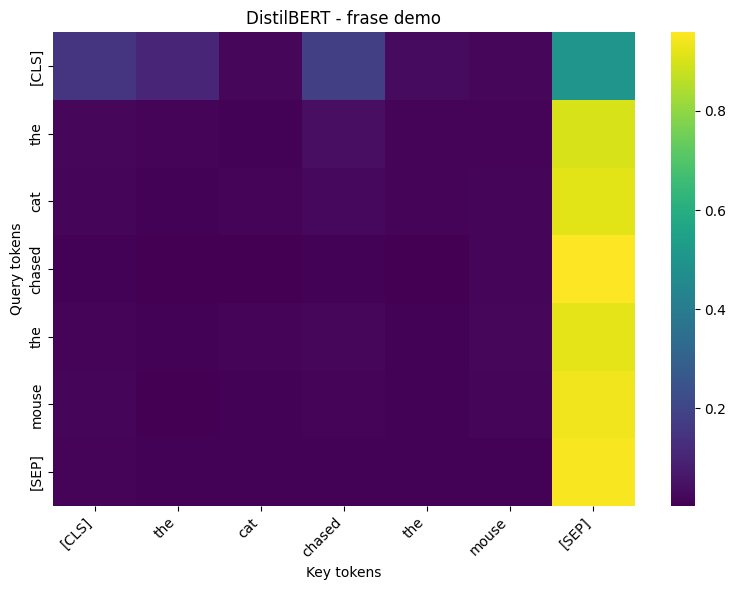

In [7]:
def plot_heatmap(tokens, matriz, titulo='Matriz de atencion'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        matriz,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='viridis',
        annot=False,
    )
    plt.title(titulo)
    plt.xlabel('Key tokens')
    plt.ylabel('Query tokens')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_heatmap(tokens_demo, attn_demo, 'DistilBERT - frase demo')

## 5) Analisis por categoria del CSV

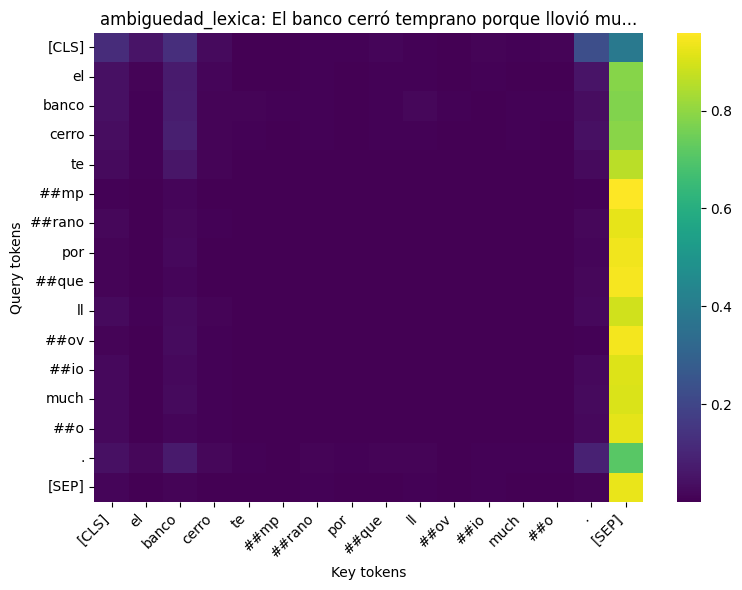

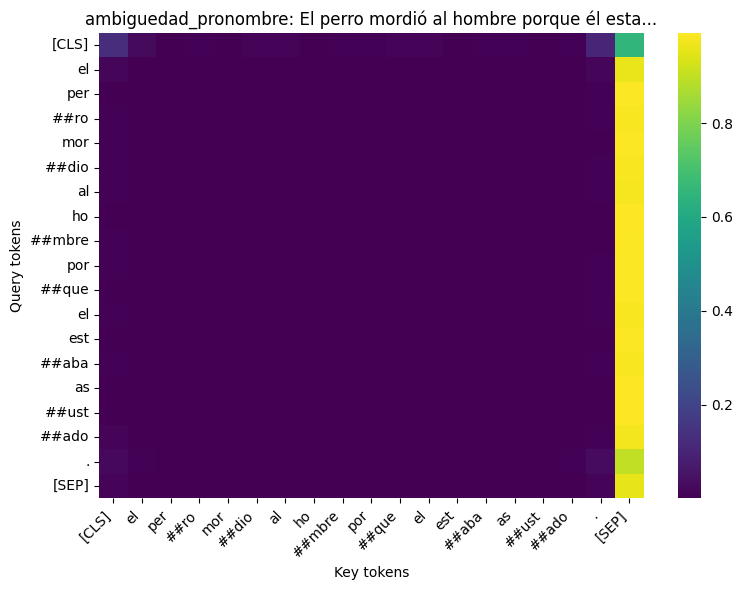

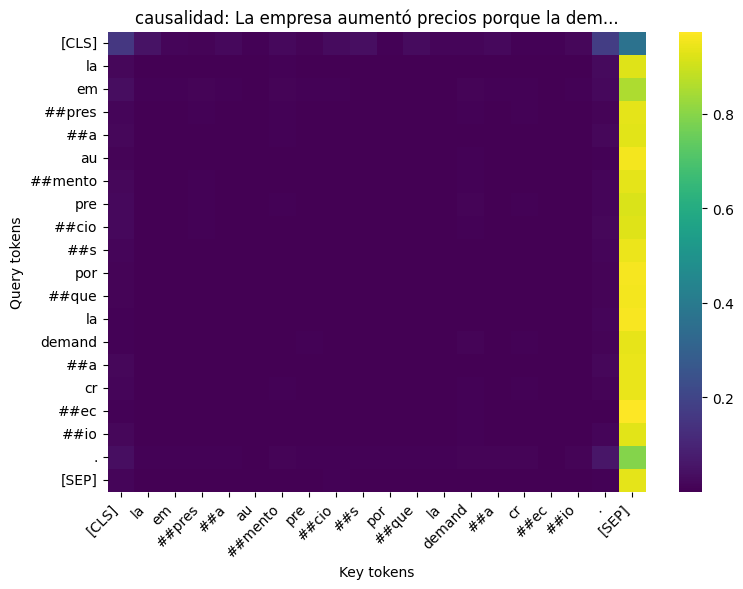

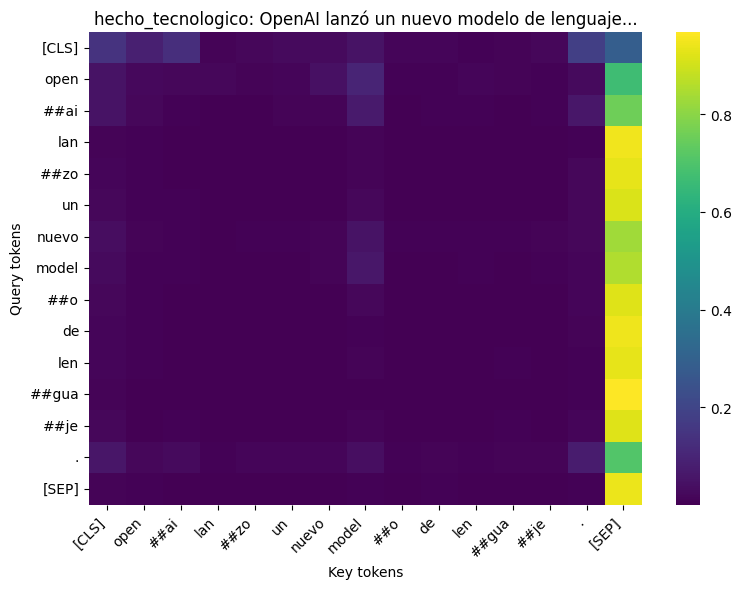

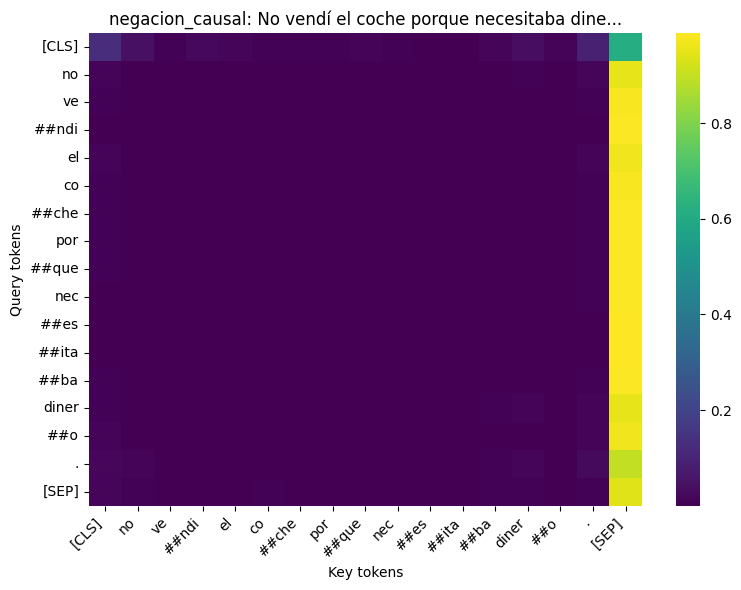

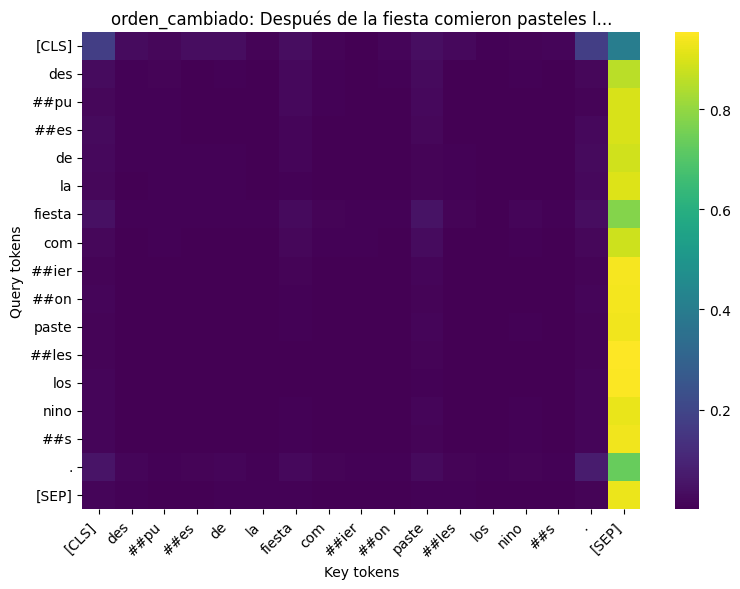

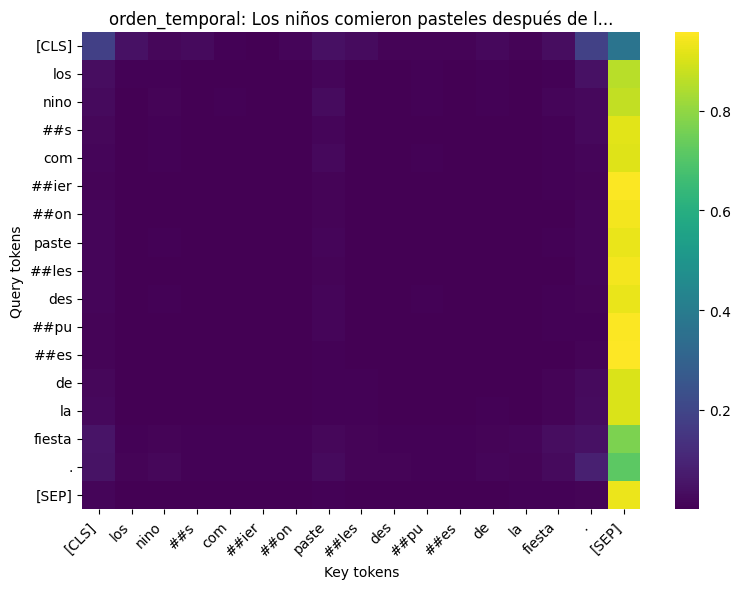

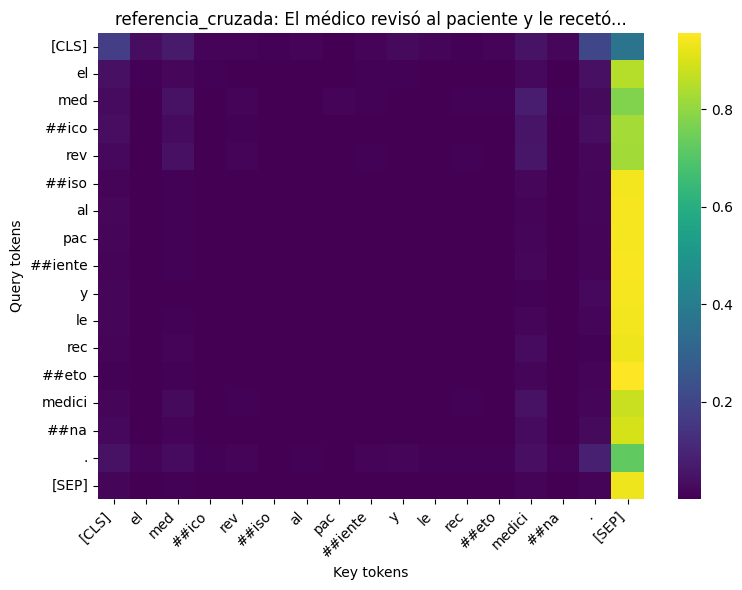

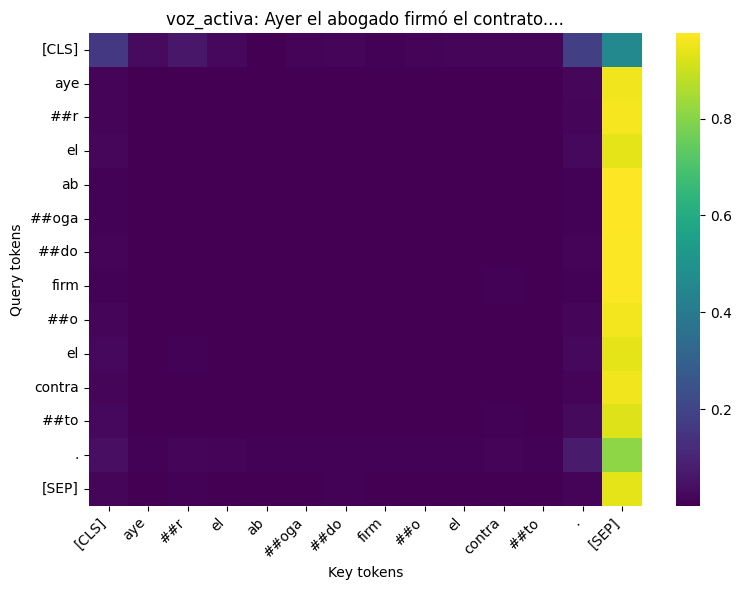

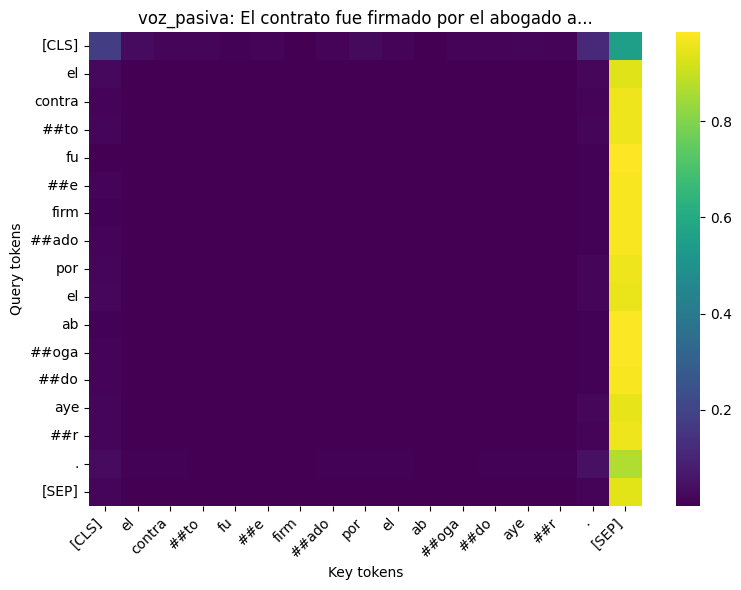

In [8]:
# Seleccionamos una frase por tipo de ambiguedad
muestras = df_frases.groupby('nota', as_index=False).first()

for _, row in muestras.iterrows():
    frase = row['frase']
    categoria = row['nota']
    tokens, mat = obtener_atencion(frase)
    plot_heatmap(tokens, mat, f"{categoria}: {frase[:40]}...")

## 6) Interpretacion cualitativa

In [9]:
# Calculamos que token recibe mas atencion promedio en cada fila
promedio_por_query = attn_demo.mean(axis=1)
interpretacion = pd.DataFrame({
    'token_query': tokens_demo,
    'atencion_promedio': promedio_por_query,
})
display(interpretacion.sort_values('atencion_promedio', ascending=False))

,token_query,atencion_promedio
1,the,0.142857
2,cat,0.142857
3,chased,0.142857
4,the,0.142857
5,mouse,0.142857
6,[SEP],0.142857
0,[CLS],0.142857


## Resultados
Visualizamos matrices de atencion para frases del CSV y una demo en ingles, identificando patrones por capa y cabeza.

## Conclusiones
La atencion no es explicabilidad perfecta, pero orienta sobre dependencias lexicas. DistilBERT ofrece un equilibrio util entre costo e interpretacion.

## Ejercicios guiados resueltos
**Ejercicio:** Compara cabeza 0 vs cabeza 1 en la misma frase.

**Solucion:**

In [10]:
t0, a0 = obtener_atencion('The lawyer signed the contract', cabeza=0)
t1, a1 = obtener_atencion('The lawyer signed the contract', cabeza=1)
print('Shapes:', a0.shape, a1.shape)
print('Diferencia media abs:', abs(a0 - a1).mean())

Shapes: (7, 7) (7, 7)
Diferencia media abs: 0.035565227


## Ejercicios propuestos
1. Promedia atencion de todas las cabezas de la ultima capa.
2. Traduce frases del CSV y repite el analisis.
3. Identifica tokens `[CLS]` y `[SEP]` en los heatmaps.

## Preguntas de reflexion
1. Por que distintas cabezas pueden especializarse?
2. Que riesgos hay al sobre-interpretar un heatmap?
3. Como afecta la longitud de la frase a la legibilidad del mapa?